Meilleurs paramètres RF : {'rf__max_depth': None, 'rf__min_samples_split': 2, 'rf__n_estimators': 50}
Score moyen CV (Random Forest) : 61.85%

===== RANDOM FOREST =====
              precision    recall  f1-score   support

           0       0.68      0.89      0.77       908
           1       0.41      0.16      0.23       451

    accuracy                           0.65      1359
   macro avg       0.55      0.52      0.50      1359
weighted avg       0.59      0.65      0.59      1359


===== GRADIENT BOOSTING =====
              precision    recall  f1-score   support

           0       0.67      0.98      0.79       908
           1       0.31      0.02      0.04       451

    accuracy                           0.66      1359
   macro avg       0.49      0.50      0.42      1359
weighted avg       0.55      0.66      0.54      1359



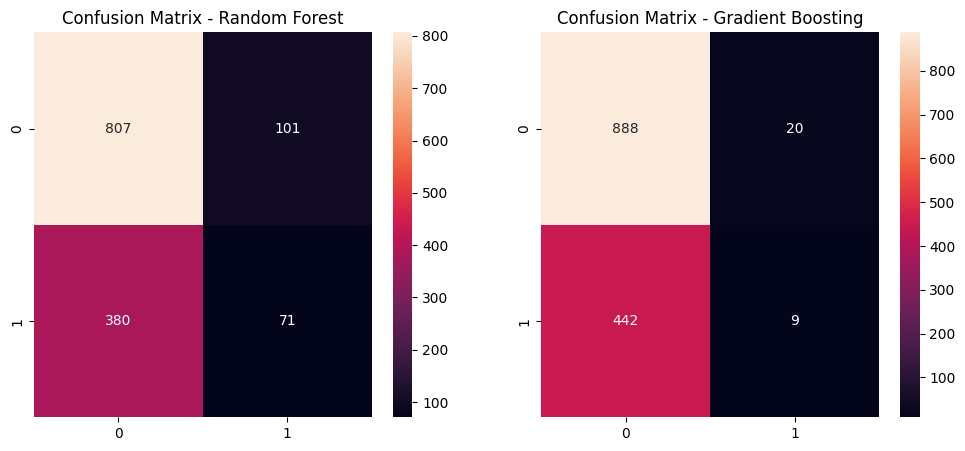

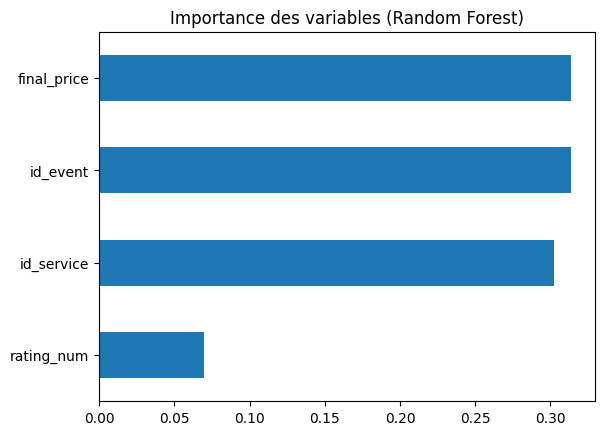

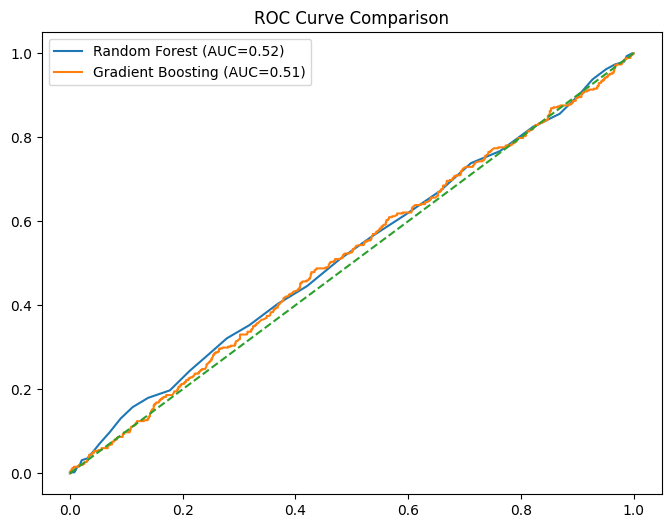

In [7]:
# 1. IMPORTS
# =============================
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

# =============================
# 2. CHARGEMENT DES DONNÉES
# =============================
df_res = pd.read_csv('Fact_reservation.csv', encoding='latin1')
df_events = pd.read_csv('dim_events.csv', encoding='latin1', on_bad_lines='skip')
df_service = pd.read_csv('dim_service.csv', encoding='latin1')
df_eval = pd.read_csv('dim_eval.csv', encoding='latin1')
# =============================
# 3. MERGE DES TABLES
# =============================
data = df_res.merge(df_events, on='id_event', how='left')
data = data.merge(df_service, on='id_service', how='left')
data = data.merge(df_eval, on='id_evaluation', how='left')

# =============================
# 4. PRÉPARATION DES DONNÉES
# =============================
# Target
data['is_canceled'] = data['id_status'].apply(lambda x: 1 if x == 3 else 0)

# Encodage
le = LabelEncoder()
data['rating_num'] = le.fit_transform(data['rating'].astype(str))

# Features
features = ['id_event', 'id_service', 'rating_num', 'final_price']
X = data[features].fillna(0)
y = data['is_canceled']

# =============================
# 5. TRAIN / TEST SPLIT
# =============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =============================
# 6. RANDOM FOREST + GRIDSEARCH
# =============================
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])

param_grid = {
    'rf__n_estimators': [50, 100],
    'rf__max_depth': [None, 10],
    'rf__min_samples_split': [2, 5]
}

grid_search = GridSearchCV(pipeline_rf, param_grid, cv=5)
grid_search.fit(X_train, y_train)

best_rf = grid_search.best_estimator_

print("Meilleurs paramètres RF :", grid_search.best_params_)

# =============================
# 7. GRADIENT BOOSTING
# =============================
pipeline_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', GradientBoostingClassifier())
])

pipeline_gb.fit(X_train, y_train)

# =============================
# 8. CROSS VALIDATION
# =============================
cv_scores = cross_val_score(best_rf, X_train, y_train, cv=5)
print(f"Score moyen CV (Random Forest) : {cv_scores.mean():.2%}")

# =============================
# 9. PRÉDICTIONS
# =============================
y_pred_rf = best_rf.predict(X_test)
y_pred_gb = pipeline_gb.predict(X_test)

# =============================
# 10. ÉVALUATION
# =============================
print("\n===== RANDOM FOREST =====")
print(classification_report(y_test, y_pred_rf))

print("\n===== GRADIENT BOOSTING =====")
print(classification_report(y_test, y_pred_gb))

# =============================
# 11. MATRICES DE CONFUSION
# =============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")

plt.subplot(1,2,2)
sns.heatmap(confusion_matrix(y_test, y_pred_gb), annot=True, fmt='d')
plt.title("Confusion Matrix - Gradient Boosting")

plt.show()

# =============================
# 12. FEATURE IMPORTANCE
# =============================
importances = best_rf.named_steps['rf'].feature_importances_

pd.Series(importances, index=features).sort_values().plot(kind='barh')
plt.title("Importance des variables (Random Forest)")
plt.show()

# =============================
# 13. COURBE ROC
# =============================
y_prob_rf = best_rf.predict_proba(X_test)[:,1]
y_prob_gb = pipeline_gb.predict_proba(X_test)[:,1]

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_prob_gb)

plt.figure(figsize=(8,6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc(fpr_rf, tpr_rf):.2f})')
plt.plot(fpr_gb, tpr_gb, label=f'Gradient Boosting (AUC={auc(fpr_gb, tpr_gb):.2f})')
plt.plot([0,1],[0,1],'--')

plt.title("ROC Curve Comparison")
plt.legend()
plt.show()
